In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import torch
import matplotlib.pyplot as plt
from src.data_processing.utils import set_seed
import pandas as pd
import joblib
from datetime import datetime
import yfinance as yf

from src.models.TimeGAN_torch.conditional_timegan import CondTimeGAN
from src.models.TimeGAN_torch.metrics.discriminative_metrics import discriminative_score_metrics
from src.models.TimeGAN_torch.metrics.predictive_metrics import predictive_score_metrics
from src.models.TimeGAN_torch.metrics.visualization_metrics import visualization
from src.data_processing.utils import TimeSeriesDataset, KFoldTimeSeries, save_synth_data, prepare_condtimegan_dataset
from src.data_processing.signals import get_sp500_market_regime


%load_ext autoreload
%autoreload 2

In [2]:
# Need to set random seed for libraries, GPU, etc. for reproducibility 

set_seed(42)

Random seed set to: 42


## Set Network Parameters

seq_len is the length of the time series sequences. In this case seq_len=24 which represents 24 consecutive trading days
n_seq is the number of features, the CBOE VIX_history.csv dataset provided 4 features (CLOSE, LOW, HIGH, OPEN)

**going to incorportate monthly returns and "market regime" for now to use as conditional variables, will replace with markert-wide RV after testing the model**

In [3]:
# Newtork parameters
parameters = dict()

parameters['module'] = 'gru'
parameters['hidden_dim'] = 32
parameters['num_layers'] = 3
parameters['batch_size'] = 128
parameters['seq_len'] = 21
parameters['lr'] = 2e-4
parameters['device'] = torch.device("cuda" if torch.cuda.is_available() else "cpu")
parameters['epochs'] = 200
parameters['dataset_name'] = 'VIX'
parameters["cond_dim"] = 4

In [4]:
data_path = './data/real_data/VIX_History.csv'
scaler_path = './model_checkpoints/scalers/scaler_VIX.pkl'

# Load the VIX history data and remove unwanted initial rows
all_data = pd.read_csv(data_path).iloc[505:].reset_index(drop=True)

# Correct the date format in the DATE column
all_data['DATE'] = [datetime.strptime(date, '%m/%d/%Y').strftime('%Y-%m-%d') for date in all_data['DATE']]

# Fetch S&P 500 data for the corresponding date range
sp500_data = get_sp500_market_regime(start_date=all_data['DATE'].iloc[0], end_date=all_data['DATE'].iloc[-1])

# Merge the datasets on the DATE column to align them
merged_data = pd.merge(all_data, sp500_data, left_on='DATE', right_on='Date', how='inner')

# Remove rows with any NaN values to ensure data quality
cleaned_data = merged_data.dropna().reset_index(drop=True)

# Reset start of data since there monthly returns were calculated
cleaned_data = cleaned_data.iloc[1:]

# Remove the DATE column
cleaned_data.drop(['DATE'], axis=1, inplace=True)
cleaned_data.drop(['Date'], axis=1, inplace=True)

parameters['n_seq'] = cleaned_data.shape[1] - 2

[*********************100%***********************]  1 of 1 completed


In [8]:
# Apply function to dataset
train_data, val_data, test_data = prepare_condtimegan_dataset(cleaned_data)

## Run TimeGAN for synthetic time-series data generation

In [10]:
# Run TimeGAN
model = CondTimeGAN(parameters)

Model initialized with ID: VIX_20250228_172134_b82c7c89_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4


In [11]:
model.train(train_data,
            val_data,
            ae_iters=parameters['epochs'], 
            sup_iters=parameters['epochs'], 
            joint_iters=parameters['epochs'], 
            patience = 15)

[Training] Phase 1: Autoencoder
[Autoencoder] Epoch 0/200, Train Loss: 3.0081, Val Loss: 1.9904
[Autoencoder] Epoch 10/200, Train Loss: 0.4504, Val Loss: 0.4816
[Autoencoder] Epoch 20/200, Train Loss: 0.2598, Val Loss: 0.2923
[Autoencoder] Epoch 30/200, Train Loss: 0.2123, Val Loss: 0.2280
[Autoencoder] Epoch 40/200, Train Loss: 0.1876, Val Loss: 0.1976
[Autoencoder] Epoch 50/200, Train Loss: 0.1750, Val Loss: 0.1799
[Autoencoder] Epoch 60/200, Train Loss: 0.1646, Val Loss: 0.1641
[Autoencoder] Epoch 70/200, Train Loss: 0.1581, Val Loss: 0.1628
[Autoencoder] Epoch 80/200, Train Loss: 0.1539, Val Loss: 0.1549
[Autoencoder] Epoch 90/200, Train Loss: 0.1489, Val Loss: 0.1510
[Autoencoder] Epoch 100/200, Train Loss: 0.1441, Val Loss: 0.1493
[Autoencoder] Epoch 110/200, Train Loss: 0.1414, Val Loss: 0.1509
[Autoencoder] Epoch 120/200, Train Loss: 0.1402, Val Loss: 0.1475
[Autoencoder] Epoch 130/200, Train Loss: 0.1362, Val Loss: 0.1460
[Autoencoder] Epoch 140/200, Train Loss: 0.1374, Val Lo

6.256311484745571

## Evaluate the generated data

[Model Loaded] Successfully loaded model from ./model_checkpoints/VIX/VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4 (ID: VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4)


Generated 90 samples for condition 0. Shape: (90, 21, 4)


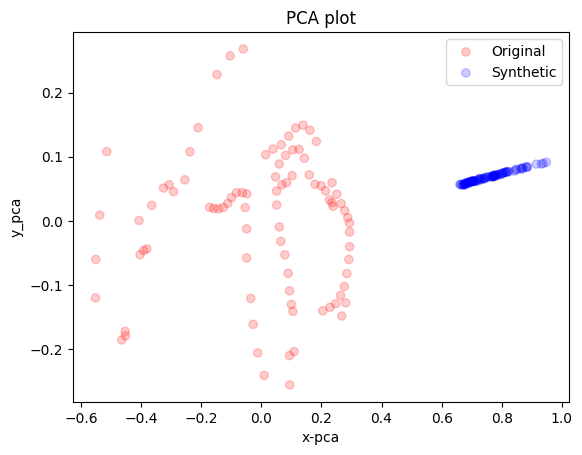

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 180 samples in 0.001s...
[t-SNE] Computed neighbors for 180 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 180 / 180
[t-SNE] Mean sigma: 0.054004
[t-SNE] KL divergence after 250 iterations with early exaggeration: 39.687019
[t-SNE] KL divergence after 300 iterations: 0.087463


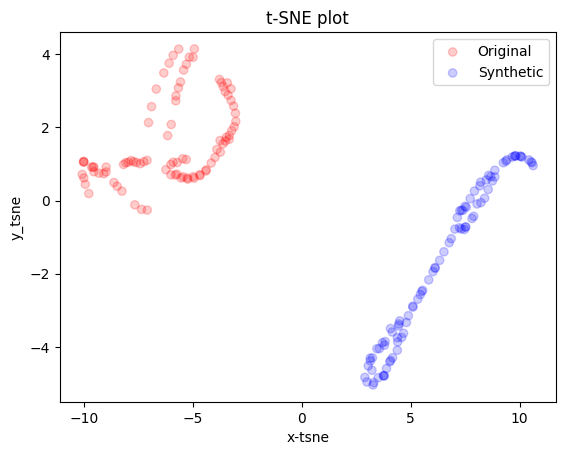

Generated 142 samples for condition 1. Shape: (142, 21, 4)


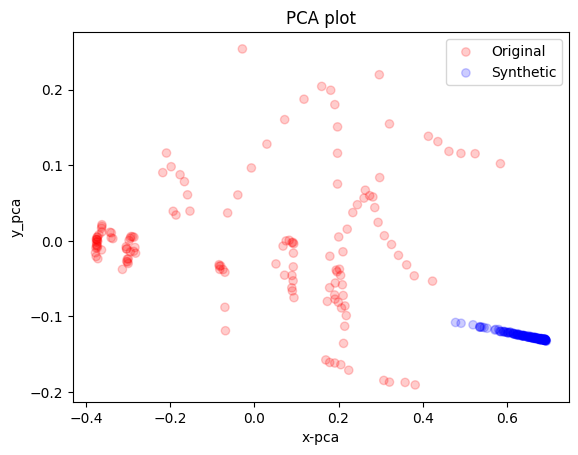

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 284 samples in 0.001s...
[t-SNE] Computed neighbors for 284 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 284 / 284
[t-SNE] Mean sigma: 0.013388
[t-SNE] KL divergence after 250 iterations with early exaggeration: 42.587410
[t-SNE] KL divergence after 300 iterations: 0.146828


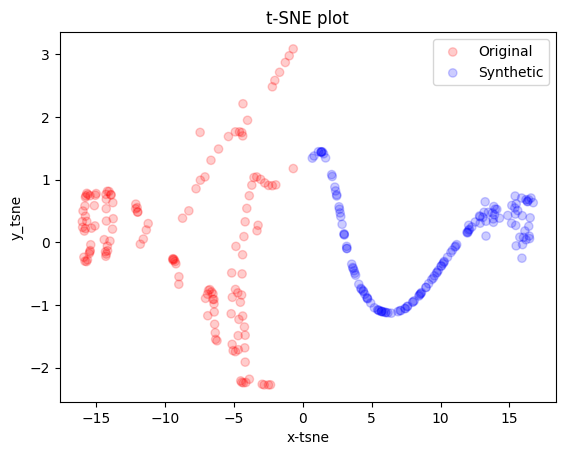

Generated 580 samples for condition 2. Shape: (580, 21, 4)


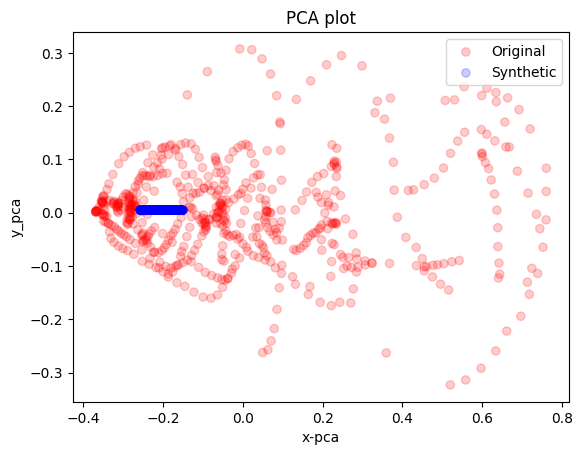

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 1160 samples in 0.001s...
[t-SNE] Computed neighbors for 1160 samples in 0.039s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1160
[t-SNE] Computed conditional probabilities for sample 1160 / 1160
[t-SNE] Mean sigma: 0.002780
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.786598
[t-SNE] KL divergence after 300 iterations: 0.664389


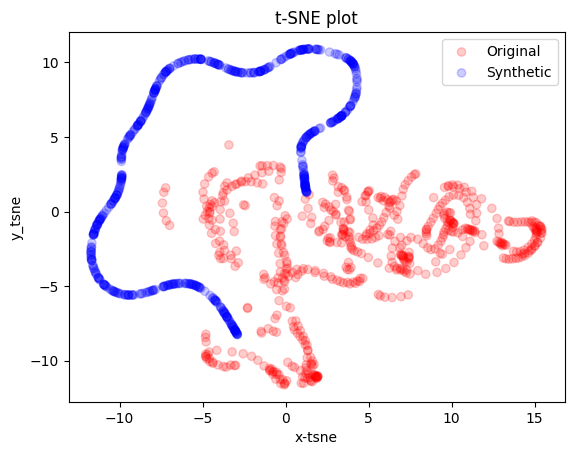

In [19]:
def evaluate_generated_sequences(model, test_dataset, visualization_methods=['pca', 'tsne']):
    """
    Evaluates the conditioned generated sequences for each market regime.
    
    Args:
        model: Trained Conditional TimeGAN model.
        test_dataset: Instance of CondTimeSeriesDataset containing test data.
        visualization_methods: List of visualization methods to apply (default: PCA & t-SNE).
        
    Returns:
        synthetic_data_dict: Dictionary with real and generated synthetic data.
    """
    
    # Extract tensors from the Dataset
    time_series_test = test_dataset.time_series_data.numpy()  # Shape (N, seq_len, n_seq)
    condition_test = test_dataset.cond_data.numpy()  # Shape (N, cond_dim)

    # Dictionary to store results
    synthetic_data_dict = {}

    # Loop over each condition (Market Regime categories)
    for i in range(condition_test.shape[1] - 1):  # Assuming last dim is 'Monthly Return', so we exclude it
        cond_filter = condition_test[:, i] == 1.0  # Select samples for the i-th market regime

        real_data = time_series_test[cond_filter]   # Get real time-series data
        cond_data = condition_test[cond_filter]     # Get corresponding conditions

        num_samples = len(cond_data)
        if num_samples == 0:
            print(f"Skipping condition {i} (no samples found).")
            continue

        # Generate synthetic data
        synthetic_data = model.generate(num_samples=num_samples, condition=cond_data)
        synthetic_data_dict[f"condition_{i}"] = {"real": real_data, "synthetic": synthetic_data}

        print(f"Generated {num_samples} samples for condition {i}. Shape: {synthetic_data.shape}")

        # Visualization
        for method in visualization_methods:
            visualization(real_data, synthetic_data, method)

    return synthetic_data_dict

# Load the trained model
model.load_model('./model_checkpoints/VIX/VIX_20250228_164445_eb31e590_n_layers3_seq_len21_n_seq4_hidden_dim32_cond_dim4')

# Evaluate and visualize conditioned sequences
synthetic_results = evaluate_generated_sequences(model, test_data)


## Inverse-transform generated sequences

The generated sequences are normalized using MinMax(), need to inverse transform the data

In [251]:
# Load the scaler
scaler_path = f'./model_checkpoints/scalers/scaler_{dataset_name}.pkl'
scaler = joblib.load(scaler_path)

# Reshape synthetic_data from (n_samples, n_timesteps, n_features) to (n_samples * n_timesteps, n_features)
n_samples, n_timesteps, n_features = synthetic_data.shape
synthetic_data_reshaped = synthetic_data.reshape(-1, n_features)

# Inverse transform
synthetic_data_inv = scaler.inverse_transform(synthetic_data_reshaped)

# Reshape back to (n_samples, n_timesteps, n_features)
# Each of the samples would represent a single block of time (e.g. synthetic_data_inv[i])
synthetic_data_inv = synthetic_data_inv.reshape(n_samples, n_timesteps, n_features)

# Example of a single block of 24 days
synth_df = pd.DataFrame(synthetic_data_inv[0], columns=all_data.columns)

synth_df.head()

,OPEN,HIGH,LOW,CLOSE
0,14.035061,14.947085,13.785007,14.353035
1,16.443285,16.076361,15.096717,16.053020
2,14.477314,15.106624,14.513026,15.009094
3,13.207664,14.238001,13.590878,13.922525
4,14.049278,14.566343,13.713311,14.283473


In [250]:
save_synth_data(synthetic_data_inv, 
                save_dir='./data/synthetic_data',
                dataset_name=parameters['dataset_name'],
                col_names=all_data.columns.tolist())

Saved 836 VIX (seq_len=24) generated synthetic samples to ./data/synthetic_data/VIX/24
